## Grid Sweep Analysis: Correlation Heatmap and n_topics Distribution

Two figures from the BERTopic hyperparameter grid sweep results (`min_cluster_size`, `umap_n_neighbors`, `umap_n_components`, `min_samples`, swept against outcomes `n_topics` and `outlier_pct`):

1. **Correlation heatmap**, pooled across all categories in the sweep results, diagonal = 1 by construction (every variable correlates perfectly with itself). Shows which swept parameters actually drive `n_topics` and `outlier_pct`, and whether the two outcomes trade off against each other.
2. **Distribution of n_topics**, histogram with a fitted normal curve overlaid for visual reference, across every config in the sweep, no filtering. This is a genuine population distribution (all 216+ configs), not a distribution conditioned on any post-hoc "good config" selection, since filtering first would bias the shape shown and misrepresent what the sweep actually produced.

**Scalability note**: this notebook reads whatever categories exist in the sweep CSV and makes no assumption about which or how many categories are present. Running it again after the full 10-category sweep completes requires no code changes, just re-pointing `SWEEP_CSV_PATH` at the larger file (or appending to the same file and re-running).

### Install dependencies (Colab only, skip if already installed locally)

In [16]:
# Uncomment if running in Colab or a fresh environment
# !pip install pandas numpy matplotlib scipy -q

### Configuration

In [1]:
import os

# --- Input: the grid sweep results CSV ---
# Point this at your current 3-category file now; re-point at the full 10-category
# file later, no other changes needed, every cell below reads categories dynamically.
SWEEP_CSV_PATH = "../results/umap_ablation/bertopic_sweep_results_pdf_chunks.csv"

# --- Columns treated as swept parameters vs outcomes ---
# Kept as an explicit list, not inferred from dtypes, since 'is_scaled' is boolean and
# 'n_docs' is a per-category constant, neither belongs in the correlation matrix as a
# swept parameter, this list is the single source of truth for what goes into the heatmap.
SWEPT_PARAMS = ["min_cluster_size", "umap_n_neighbors", "umap_n_components", "min_samples"]
OUTCOMES = ["n_topics", "outlier_pct"]

# --- Correlation method ---
# Spearman, not Pearson: several of these relationships (e.g. min_cluster_size vs n_topics)
# are strongly monotonic but visibly non-linear in the raw sweep data (diminishing/accelerating
# effects at different min_cluster_size ranges, per the earlier discussion of your results).
# Pearson assumes linearity and would understate these relationships; Spearman captures monotonic
# association regardless of shape, which better matches what's actually in this data.
CORRELATION_METHOD = "spearman"

# --- Visualization settings, IEEE format ---
IEEE_COLUMN_WIDTH_INCHES = 3.5
IEEE_FULL_WIDTH_INCHES = 7.16
IEEE_FIGURE_DPI = 300

# --- Output paths ---
PROJECT_ROOT = ".."
FIGURES_DIR = os.path.join(PROJECT_ROOT, "results", "figures", "bertopic_sweep_pdf_chunks")
os.makedirs(FIGURES_DIR, exist_ok=True)

### Load sweep results

Reports which categories are present, so it's immediately visible whether this is running against the partial (3-category) or full (10-category) sweep without needing to inspect the CSV manually.

In [2]:
import pandas as pd

df = pd.read_csv(SWEEP_CSV_PATH)

print(f"Loaded {len(df)} configs across {df['category'].nunique()} categories:")
for category in sorted(df["category"].unique()):
    n_configs = len(df[df["category"] == category])
    n_docs = df[df["category"] == category]["n_docs"].iloc[0]
    print(f"  {category}: {n_configs} configs, {n_docs} docs")

Loaded 720 configs across 10 categories:
  cs.AI: 72 configs, 2060 docs
  cs.CL: 72 configs, 1363 docs
  cs.CR: 72 configs, 1517 docs
  cs.CV: 72 configs, 1250 docs
  cs.DB: 72 configs, 1768 docs
  cs.DC: 72 configs, 1826 docs
  cs.IR: 72 configs, 1371 docs
  cs.LG: 72 configs, 1937 docs
  cs.NE: 72 configs, 1668 docs
  cs.SE: 72 configs, 1956 docs


### Correlation heatmap function

**Why pooled across categories, not one matrix per category**: pooling treats every (category, config) row as one observation, giving a single, larger-sample view of how the swept parameters relate to the outcomes across the whole corpus, which is what you asked for. The tradeoff, worth stating in the paper if this figure is used there, is that pooling mixes together categories with very different population sizes (`n_docs` ranges from ~1,000 to ~14,000 across the full 10-category set), so a pooled correlation reflects the average relationship across scales, not necessarily the exact relationship within any single category. This is a reasonable summary view precisely because `min_cluster_size`'s effect on `n_topics` is a ratio-like relationship relative to population size (as shown in the earlier scaling-constant discussion), so pooling raw parameter values across differently-sized categories is a defensible simplification, not a methodological error, but it's worth one sentence acknowledging it rather than presenting the pooled matrix as if scale didn't matter.

**Diagonal = 1 explanation**: every variable is perfectly correlated with itself by definition (correlating a column against itself always yields exactly 1.0, regardless of correlation method), this isn't something to configure, it falls out of the math automatically and is included here as the standard, expected sanity-check feature of any correlation matrix.

In [3]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams.update({
    "font.size": 8,
    "font.family": "serif",
    "axes.titlesize": 9,
    "axes.labelsize": 8,
    "xtick.labelsize": 7,
    "ytick.labelsize": 7,
})


def plot_correlation_heatmap(df: pd.DataFrame, columns: list[str], method: str, out_path: str) -> pd.DataFrame:
    corr = df[columns].corr(method=method)

    fig, ax = plt.subplots(figsize=(IEEE_COLUMN_WIDTH_INCHES + 1.0, IEEE_COLUMN_WIDTH_INCHES + 1.0))
    im = ax.imshow(corr.values, cmap="RdBu_r", vmin=-1, vmax=1, aspect="equal")

    ax.set_xticks(range(len(columns)))
    ax.set_yticks(range(len(columns)))
    ax.set_xticklabels(columns, rotation=45, ha="right")
    ax.set_yticklabels(columns)

    for i in range(len(columns)):
        for j in range(len(columns)):
            value = corr.values[i, j]
            text_color = "white" if abs(value) > 0.6 else "black"
            ax.text(j, i, f"{value:.2f}", ha="center", va="center", color=text_color, fontsize=7)

    cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    cbar.set_label(f"{method.capitalize()} correlation")

    ax.set_title(f"Parameter-outcome correlation\n(pooled across {df['category'].nunique()} categories, n={len(df)})")

    fig.tight_layout()
    fig.savefig(out_path, dpi=IEEE_FIGURE_DPI, bbox_inches="tight")
    plt.show()

    return corr

### Generate the heatmap

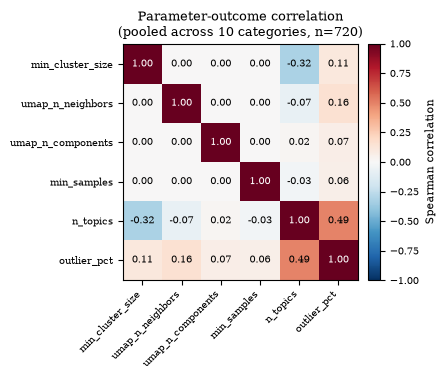

Saved ..\results\figures\bertopic_sweep\parameter_correlation_heatmap_spearman.png
Saved ..\results\figures\bertopic_sweep\parameter_correlation_matrix_spearman.csv


,min_cluster_size,umap_n_neighbors,umap_n_components,min_samples,n_topics,outlier_pct
min_cluster_size,1.000000,0.000000,0.000000,0.000000,-0.320275,0.108245
umap_n_neighbors,0.000000,1.000000,0.000000,0.000000,-0.071181,0.155024
umap_n_components,0.000000,0.000000,1.000000,0.000000,0.022711,0.066854
min_samples,0.000000,0.000000,0.000000,1.000000,-0.026771,0.060545
n_topics,-0.320275,-0.071181,0.022711,-0.026771,1.000000,0.492773
outlier_pct,0.108245,0.155024,0.066854,0.060545,0.492773,1.000000


In [20]:
heatmap_columns = SWEPT_PARAMS + OUTCOMES
heatmap_path = os.path.join(FIGURES_DIR, f"parameter_correlation_heatmap_{CORRELATION_METHOD}.png")

corr_matrix = plot_correlation_heatmap(df, heatmap_columns, CORRELATION_METHOD, heatmap_path)
print(f"Saved {heatmap_path}")

corr_csv_path = os.path.join(FIGURES_DIR, f"parameter_correlation_matrix_{CORRELATION_METHOD}.csv")
corr_matrix.to_csv(corr_csv_path)
print(f"Saved {corr_csv_path}")

corr_matrix

### n_topics distribution function

**Why a histogram with a fitted normal curve overlaid, not a claim that n_topics is naturally Gaussian**: grid search outcomes have no inherent reason to follow a normal distribution, they're the result of a deliberately chosen parameter grid, not a natural random process. The fitted curve here is a standard visual reference (mean and standard deviation of the observed data), included because it's conventional in this kind of distribution figure and makes the spread/skew of the data easier to read at a glance, not because the underlying data-generating process is assumed to be Gaussian. This distinction matters if a reviewer asks why a bell curve was fit to non-random data, the honest answer is "as a descriptive visual aid over the observed spread," not "because n_topics is theoretically expected to be normal."

**No filtering applied**: every config in the sweep (including the collapse-to-2-topics extremes and the 100+ topic extremes) is included. Filtering first to only "reasonable" configs was considered and explicitly rejected, since that would make the plotted distribution a description of your own selection criteria rather than a description of what the grid search actually produced, and would need to be caveated every time the figure is shown.

In [4]:
from scipy import stats


def plot_ntopics_distribution(df: pd.DataFrame, out_path: str, by_category: bool = False) -> None:
    values = df["n_topics"].values
    mean, std = values.mean(), values.std()

    fig, ax = plt.subplots(figsize=(IEEE_COLUMN_WIDTH_INCHES, 2.4))

    n_bins = min(30, max(10, len(values) // 8))
    counts, bin_edges, _ = ax.hist(
        values, bins=n_bins, density=True, color="#4C72B0", alpha=0.65,
        edgecolor="white", linewidth=0.4, label="Observed (all configs)",
    )

    x_range = np.linspace(values.min(), values.max(), 300)
    fitted_curve = stats.norm.pdf(x_range, mean, std)
    ax.plot(x_range, fitted_curve, color="#C44E52", linewidth=1.5, label=f"Fitted normal (mu={mean:.1f}, sigma={std:.1f})")

    ax.axvline(mean, color="#C44E52", linestyle="--", linewidth=0.8, alpha=0.7)

    ax.set_xlabel("n_topics")
    ax.set_ylabel("Density")
    title_suffix = f"across {df['category'].nunique()} categories, n={len(df)} configs"
    ax.set_title(f"Distribution of n_topics ({title_suffix})")
    ax.legend(fontsize=6)
    ax.grid(alpha=0.25, axis="y")

    fig.tight_layout()
    fig.savefig(out_path, dpi=IEEE_FIGURE_DPI, bbox_inches="tight")
    plt.show()

    print(f"n={len(values)}, mean={mean:.2f}, std={std:.2f}, min={values.min()}, max={values.max()}")
    print(f"Shapiro-Wilk normality test: statistic={stats.shapiro(values)[0]:.4f}, p={stats.shapiro(values)[1]:.4g}")
    print("(p < 0.05 indicates the data significantly deviates from normal, expected for grid-search outcomes,")
    print(" reported for transparency, not as evidence the fitted curve should be trusted as a generative model.)")

### Generate the distribution figure

Includes a Shapiro-Wilk normality test purely for transparency, a low p-value (data significantly non-normal) is the expected, honest result here, and reporting it alongside the fitted curve prevents the figure from overclaiming what it shows.

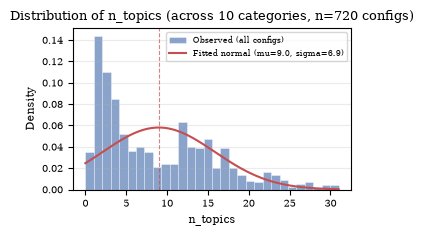

n=720, mean=8.99, std=6.87, min=0, max=31
Shapiro-Wilk normality test: statistic=0.9101, p=3.32e-20
(p < 0.05 indicates the data significantly deviates from normal, expected for grid-search outcomes,
 reported for transparency, not as evidence the fitted curve should be trusted as a generative model.)
Saved ..\results\figures\bertopic_sweep_pdf_chunks\n_topics_distribution_all_configs.png


In [5]:
dist_path = os.path.join(FIGURES_DIR, "n_topics_distribution_all_configs.png")
plot_ntopics_distribution(df, dist_path)
print(f"Saved {dist_path}")

### Optional: per-category distribution comparison

Small-multiples view, one subplot per category, same n_topics data as above but split out, useful for checking whether the pooled distribution's shape is being driven by one category (e.g. cs.CV's wider parameter range) rather than reflecting all categories similarly. Scales automatically to however many categories are in the loaded CSV, no manual subplot-grid sizing needed.

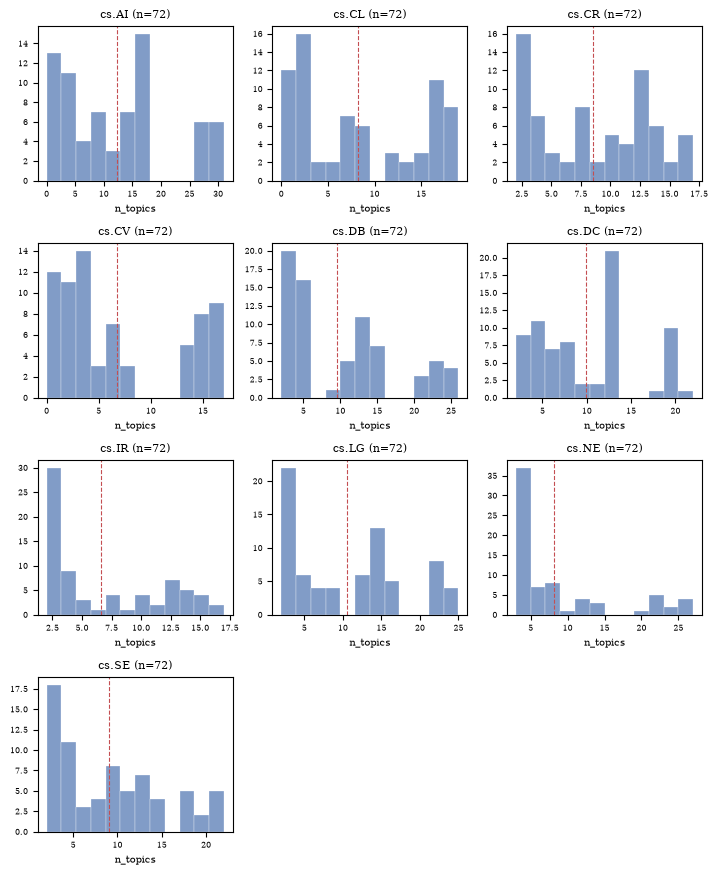

Saved ..\results\figures\bertopic_sweep_pdf_chunks\n_topics_distribution_per_category.png


In [6]:
categories = sorted(df["category"].unique())
n_cats = len(categories)
n_cols = min(3, n_cats)
n_rows = int(np.ceil(n_cats / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(IEEE_FULL_WIDTH_INCHES, 2.2 * n_rows), squeeze=False)

for i, category in enumerate(categories):
    ax = axes[i // n_cols][i % n_cols]
    subset = df[df["category"] == category]["n_topics"].values

    ax.hist(subset, bins=min(15, max(5, len(subset) // 6)), color="#4C72B0", alpha=0.7, edgecolor="white", linewidth=0.3)
    ax.axvline(subset.mean(), color="#C44E52", linestyle="--", linewidth=0.8)
    ax.set_title(f"{category} (n={len(subset)})", fontsize=8)
    ax.set_xlabel("n_topics", fontsize=7)
    ax.tick_params(labelsize=6)

# hide unused subplot slots if categories don't evenly fill the grid
for j in range(n_cats, n_rows * n_cols):
    axes[j // n_cols][j % n_cols].axis("off")

fig.tight_layout()
percategory_path = os.path.join(FIGURES_DIR, "n_topics_distribution_per_category.png")
fig.savefig(percategory_path, dpi=IEEE_FIGURE_DPI, bbox_inches="tight")
plt.show()
print(f"Saved {percategory_path}")

### Reading the results

- In the heatmap, look at the `min_cluster_size` row/column against `n_topics` and `outlier_pct`. Given the earlier analysis of this sweep, expect a strong negative correlation with `n_topics` (larger `min_cluster_size` -> fewer topics) and a weaker, less monotonic relationship with `outlier_pct` (the sweep showed outlier_pct rising then sometimes falling again at extreme `min_cluster_size`, so this correlation may look moderate rather than strong, which is itself informative, it shows the relationship isn't simply linear).
- `n_topics` vs `outlier_pct` correlation tells you whether these two outcomes trade off against each other in this data (fewer topics costing you a worse outlier rate, or vice versa) or move somewhat independently, worth a sentence either way in the methodology section justifying why the eventual chosen config had to balance both rather than optimizing either alone.
- The distribution figure's fitted mean and std, reported directly in the printed output, are useful descriptive numbers for the paper ("across 216 grid configurations spanning 3 categories, n_topics ranged from 2 to 141 with mean X and std Y"), giving a reader a sense of how wide the swept parameter space's effect actually was, before your calibrated formula narrows it down to the small usable range you settled on.